# Instant-NGP — Visual Experiments (a 2D multiresolution hash grid)

> **Goal:** Build Instant-NGP's **multiresolution hash encoding** from scratch in 2D and see why it is fast: a learned feature grid + a *tiny* MLP fits an image as well as a big positional-encoding MLP but converges faster; the multiresolution levels go coarse→fine; and the hash-table size $T$ trades memory against collision artifacts.

## What we'll explore

| # | Experiment | Question answered |
|---|---|---|
| 1 | **The encoder** | What are the $L$ multiresolution grids and where do collisions begin? |
| 2 | **Hash grid vs PE** | Does a *tiny* MLP + hash grid match a big PE-MLP, and converge faster? |
| 3 | **Multiresolution** | What does each resolution level contribute (coarse → fine)? |
| 4 | **Hash collisions** | How does the table size $T$ trade memory vs collision artifacts? |

---
**Linked theory:** [research/05-instant-ngp.md](../research/05-instant-ngp.md)  ·  **Chạy:** `uv run jupyter lab` từ thư mục `latent-anything-theory/` (cần các package trong `pyproject.toml`).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)
plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11,
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa', 'axes.grid': True, 'grid.alpha': 0.35,
})
print('Setup complete. torch', torch.__version__)

Setup complete. torch 2.12.0+cpu


---
## A shared toolkit: the hash-grid encoder, a PE baseline, and a target image

`HashGrid2D` stores learnable feature vectors at the vertices of $L$ grids whose resolution grows geometrically. A point looks up its surrounding 4 vertices on each level (bilinear interpolation), via a **direct index** when the grid fits in the table and a **spatial hash** when it does not. The features from all levels are concatenated and fed to a tiny MLP. `PEINR` is the positional-encoding baseline (Fourier features + a larger MLP).

In [2]:
class HashGrid2D(nn.Module):
    """Multiresolution (hash) feature grid over [0,1]^2."""
    def __init__(self, L=8, T=2**12, Fdim=2, N_min=8, N_max=160, seed=0):
        super().__init__()
        g = torch.Generator().manual_seed(seed)
        b = np.exp((np.log(N_max) - np.log(N_min)) / (L - 1))
        self.res = [int(round(N_min * b ** l)) for l in range(L)]
        self.L, self.T, self.Fdim, self.out_dim = L, T, Fdim, L * Fdim
        self.PI1 = 2654435761
        self.tables = nn.ParameterList()
        self.direct = []
        for N in self.res:
            cells = (N + 1) * (N + 1)
            size = min(T, cells)
            self.direct.append(cells <= T)
            self.tables.append(nn.Parameter((torch.rand(size, Fdim, generator=g) * 2 - 1) * 1e-4))

    def _idx(self, ix, iy, l):
        N = self.res[l]
        if self.direct[l]:
            return (ix * (N + 1) + iy).long()
        return (torch.bitwise_xor(ix.long(), (iy.long() * self.PI1)) % self.T).long()

    def encode(self, x, level_mask=None):
        feats = []
        for l, N in enumerate(self.res):
            c = x * N
            c0 = torch.floor(c).long()
            w = c - c0
            acc = 0.0
            for dx in (0, 1):
                for dy in (0, 1):
                    ix = (c0[:, 0] + dx).clamp(0, N)
                    iy = (c0[:, 1] + dy).clamp(0, N)
                    f = self.tables[l][self._idx(ix, iy, l)]
                    wx = w[:, 0] if dx else (1 - w[:, 0])
                    wy = w[:, 1] if dy else (1 - w[:, 1])
                    acc = acc + (wx * wy)[:, None] * f
            if level_mask is not None:
                acc = acc * level_mask[l]
            feats.append(acc)
        return torch.cat(feats, dim=1)


class HashINR(nn.Module):
    def __init__(self, hidden=32, **kw):
        super().__init__()
        self.grid = HashGrid2D(**kw)
        self.mlp = nn.Sequential(nn.Linear(self.grid.out_dim, hidden), nn.ReLU(),
                                 nn.Linear(hidden, 1))
    def forward(self, x, level_mask=None):
        return self.mlp(self.grid.encode(x, level_mask))


class PEINR(nn.Module):
    """positional-encoding baseline: Fourier features + a larger MLP."""
    def __init__(self, n_freq=10, hidden=128, layers=4):
        super().__init__()
        self.freqs = 2.0 ** torch.arange(n_freq) * np.pi
        in_dim = 2 + 2 * 2 * n_freq
        mods = [nn.Linear(in_dim, hidden), nn.ReLU()]
        for _ in range(layers - 1):
            mods += [nn.Linear(hidden, hidden), nn.ReLU()]
        mods += [nn.Linear(hidden, 1)]
        self.mlp = nn.Sequential(*mods)
    def forward(self, x):
        ang = x[..., None] * self.freqs
        enc = torch.cat([torch.sin(ang), torch.cos(ang)], -1).reshape(x.shape[0], -1)
        return self.mlp(torch.cat([x, enc], -1))


def make_target(res=96):
    xs = np.linspace(0, 1, res)
    X, Y = np.meshgrid(xs, xs)
    img = 0.5 + 0.35 * np.sin(2 * np.pi * 3 * X) * np.sin(2 * np.pi * 3 * Y)   # low-freq
    img += 0.25 * (np.sin(2 * np.pi * 11 * X) > 0)                              # high-freq stripes
    r = np.sqrt((X - 0.5) ** 2 + (Y - 0.5) ** 2)
    img += 0.4 * (r < 0.18)                                                     # sharp disk
    img = (img - img.min()) / (img.max() - img.min())
    coords = torch.tensor(np.stack([X.ravel(), Y.ravel()], 1), dtype=torch.float32)
    target = torch.tensor(img.ravel()[:, None], dtype=torch.float32)
    return coords, target, img, (X, Y)


def train(model, coords, target, steps=800, lr=1e-2, seed=0):
    torch.manual_seed(seed)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    for _ in range(steps):
        opt.zero_grad()
        loss = F.mse_loss(model(coords), target)
        loss.backward(); opt.step()
        losses.append(loss.item())
    return losses

RES = 96
coords, target, img, (X, Y) = make_target(RES)
print('target image:', img.shape)

target image: (96, 96)


---
## Experiment 1: The multiresolution grids and where collisions begin

**Question:** The encoding stacks $L$ grids whose resolution grows geometrically from $N_{\min}$ to $N_{\max}$. Each level has a feature table capped at $T$ entries. At which levels does the grid outgrow the table — forcing the **spatial hash** and its collisions?

We instantiate the grid and report each level's resolution, its table size, and whether it uses direct indexing (collision-free) or hashing.

In [3]:
grid = HashGrid2D(L=8, T=2**12, Fdim=2, N_min=8, N_max=160)
print(f'T = {grid.T} entries per level\n')
print(f'{"level":>5} {"resolution":>12} {"grid vertices":>15} {"indexing":>12}')
for l, N in enumerate(grid.res):
    cells = (N + 1) ** 2
    mode = 'direct' if grid.direct[l] else 'HASH (collisions)'
    print(f'{l:>5} {N:>10}^2 {cells:>15} {mode:>18}')

T = 4096 entries per level

level   resolution   grid vertices     indexing
    0          8^2              81             direct
    1         12^2             169             direct
    2         19^2             400             direct
    3         29^2             900             direct
    4         44^2            2025             direct
    5         68^2            4761  HASH (collisions)
    6        104^2           11025  HASH (collisions)
    7        160^2           25921  HASH (collisions)


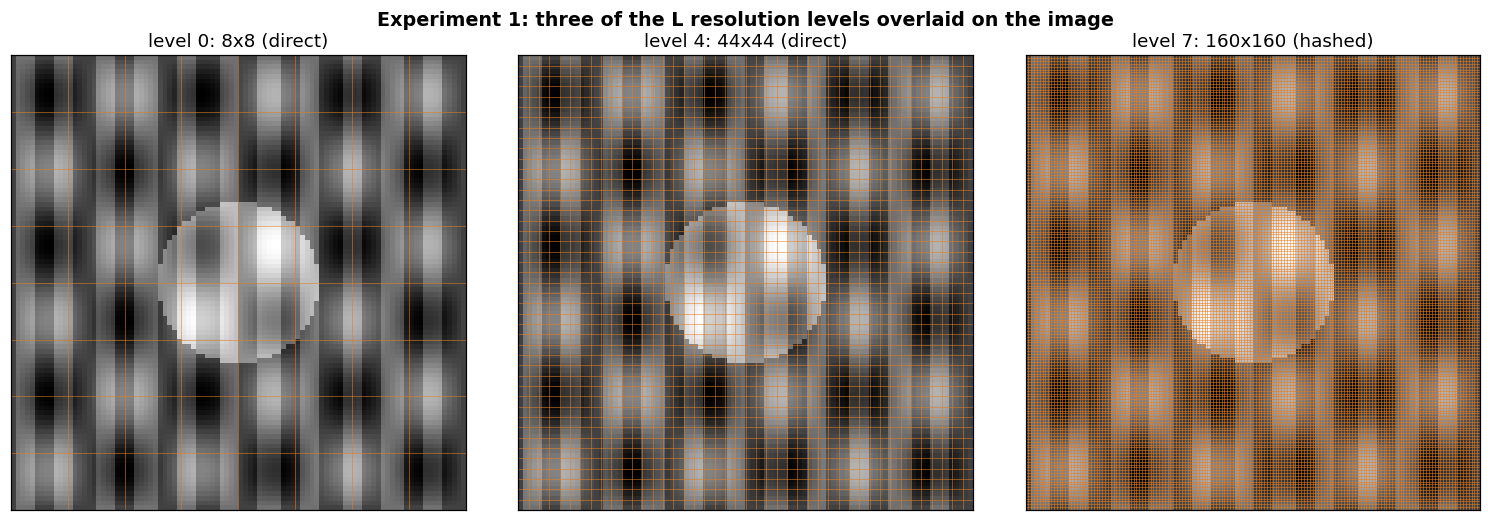

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))
fig.suptitle('Experiment 1: three of the L resolution levels overlaid on the image',
             fontsize=12.5, fontweight='bold')
for ax, l in zip(axes, [0, 4, 7]):
    N = grid.res[l]
    ax.imshow(img, extent=[0, 1, 0, 1], origin='lower', cmap='gray')
    for gx in np.linspace(0, 1, N + 1):
        ax.axvline(gx, color='#e67e22', lw=0.5, alpha=0.7)
        ax.axhline(gx, color='#e67e22', lw=0.5, alpha=0.7)
    mode = 'direct' if grid.direct[l] else 'hashed'
    ax.set_title(f'level {l}: {N}x{N} ({mode})'); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The levels are grids of geometrically increasing resolution overlaid on the image — coarse at level 0, fine at level 7. The printed table shows that coarse levels (few vertices) fit in $T$ and use **direct indexing** (collision-free), while fine levels have more vertices than $T$ and must **hash** (collisions).

2. **Why it looks this way:** The grid resolution grows geometrically but the table size is fixed at $T$. Once a level's vertex count exceeds $T$, distinct vertices are forced to share table slots — that is the hash collision the design tolerates on purpose.

3. **Key takeaway:** The encoding is a *stack* of resolutions sharing fixed-size tables. Coarse levels are clean and give global context; fine levels are crowded and collide — and the next experiments show why that is still fast and good enough.

---
## Experiment 2: Hash grid + tiny MLP vs positional encoding + big MLP

**Question:** Instant-NGP's claim is that moving capacity into a *learned* feature grid lets the MLP shrink dramatically while training faster. Does a hash grid with a tiny 1-hidden-layer MLP match a positional-encoding model with a much larger MLP — and converge in fewer steps?

We fit the same image with both and compare reconstructions, loss curves, and MLP sizes.

In [5]:
hash_inr = HashINR(hidden=32, L=8, T=2**12, Fdim=2, N_min=8, N_max=160)
pe_inr = PEINR(n_freq=10, hidden=128, layers=4)

loss_hash = train(hash_inr, coords, target, steps=800, lr=1e-2, seed=1)
loss_pe = train(pe_inr, coords, target, steps=800, lr=5e-3, seed=1)
with torch.no_grad():
    rec_hash = hash_inr(coords).numpy().reshape(RES, RES)
    rec_pe = pe_inr(coords).numpy().reshape(RES, RES)

mlp_params_hash = sum(p.numel() for p in hash_inr.mlp.parameters())
mlp_params_pe = sum(p.numel() for p in pe_inr.mlp.parameters())
print(f'hash-grid MLP params: {mlp_params_hash}   (tiny: 1 hidden layer of 32)')
print(f'PE          MLP params: {mlp_params_pe}   ({mlp_params_pe / mlp_params_hash:.0f}x larger)')
print(f'final MSE  -> hash: {loss_hash[-1]:.2e}   PE: {loss_pe[-1]:.2e}')

hash-grid MLP params: 577   (tiny: 1 hidden layer of 32)
PE          MLP params: 55169   (96x larger)
final MSE  -> hash: 3.22e-11   PE: 1.27e-04


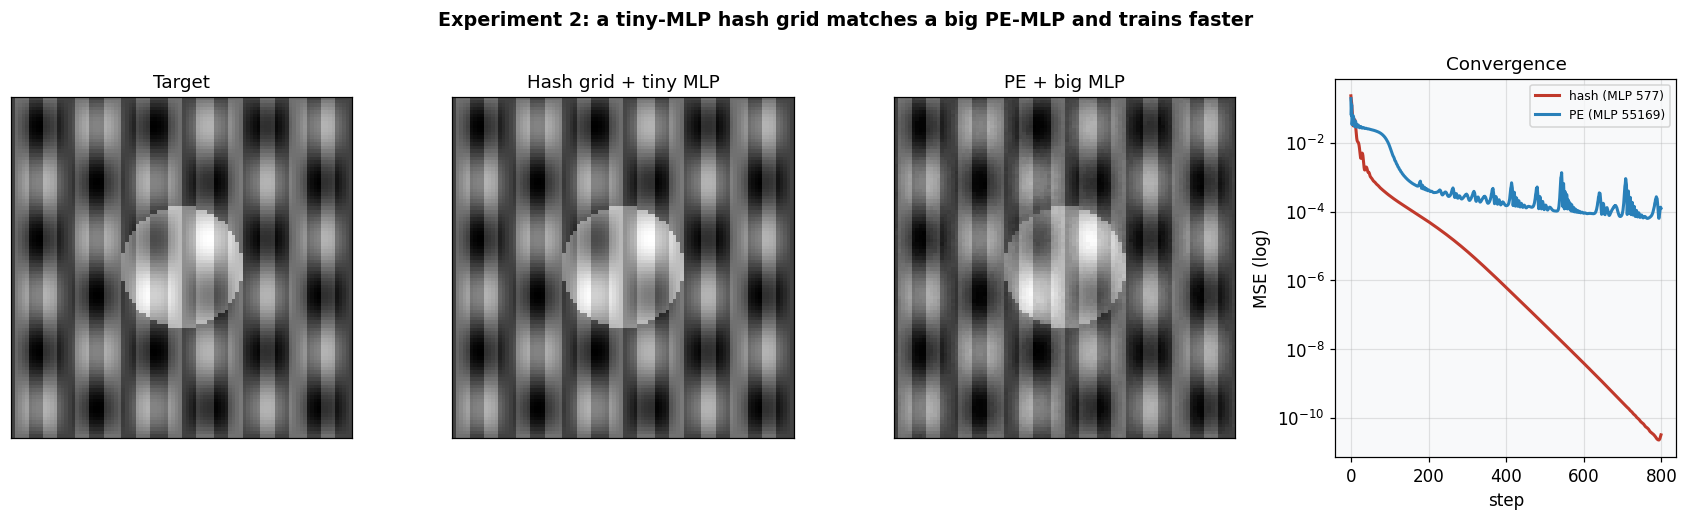

In [6]:
fig = plt.figure(figsize=(15.5, 4.8))
fig.suptitle('Experiment 2: a tiny-MLP hash grid matches a big PE-MLP and trains faster',
             fontsize=12.5, fontweight='bold')

for i, (t, im_k) in enumerate([('Target', img), ('Hash grid + tiny MLP', rec_hash),
                               ('PE + big MLP', rec_pe)]):
    ax = fig.add_subplot(1, 4, i + 1)
    ax.imshow(np.clip(im_k, 0, 1), extent=[0, 1, 0, 1], origin='lower', cmap='gray', vmin=0, vmax=1)
    ax.set_title(t); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)

ax = fig.add_subplot(1, 4, 4)
ax.plot(loss_hash, color='#c0392b', lw=2, label=f'hash (MLP {mlp_params_hash})')
ax.plot(loss_pe, color='#2980b9', lw=2, label=f'PE (MLP {mlp_params_pe})')
ax.set_yscale('log'); ax.set_xlabel('step'); ax.set_ylabel('MSE (log)')
ax.set_title('Convergence'); ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** Both models reconstruct the image well, but the hash grid uses an MLP many times smaller and its loss curve drops faster and lower in the same number of steps.

2. **Why it looks this way:** With a learned feature at every grid vertex, most of the representational work is a cheap table lookup + interpolation; the MLP only has to decode a local feature, so it can be tiny. Positional encoding instead hands the MLP fixed sinusoids and makes *it* do all the fitting, so it must be large and trains slower.

3. **Key takeaway:** Moving capacity from the network into a learned spatial table is the core of Instant-NGP's speed. The lookups are $O(1)$ and the MLP is small, which (with empty-space skipping in 3D) is what turns days of NeRF training into seconds.

---
## Experiment 3: What each resolution level contributes

**Question:** The grid is *multiresolution* — coarse levels should carry global structure, fine levels the detail. If we reconstruct using only the first $k$ levels (zeroing the rest), do we see a coarse-to-fine build-up?

We reuse the trained hash model and decode it with a growing subset of levels enabled.

In [7]:
L = hash_inr.grid.L
recons = {}
for k in [1, 2, 4, L]:
    mask = [1.0 if l < k else 0.0 for l in range(L)]
    with torch.no_grad():
        recons[k] = hash_inr(coords, level_mask=mask).numpy().reshape(RES, RES)
print('reconstructed with the first k of', L, 'levels enabled:', list(recons.keys()))

reconstructed with the first k of 8 levels enabled: [1, 2, 4, 8]


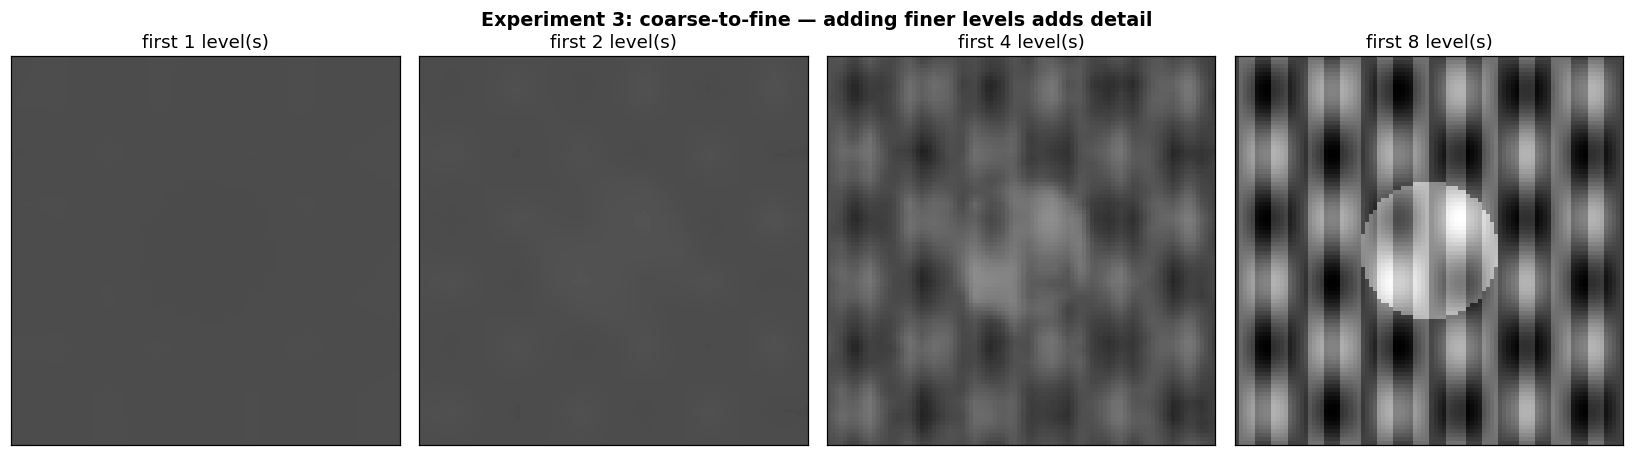

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4.2))
fig.suptitle('Experiment 3: coarse-to-fine — adding finer levels adds detail',
             fontsize=12.5, fontweight='bold')
for ax, k in zip(axes, [1, 2, 4, L]):
    ax.imshow(np.clip(recons[k], 0, 1), extent=[0, 1, 0, 1], origin='lower', cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'first {k} level(s)'); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** With only the coarsest level(s) the reconstruction is a blurry blob capturing the overall layout; as finer levels are switched on, the stripes and the sharp disk edge sharpen, until the full stack reproduces the image.

2. **Why it looks this way:** Each level resolves features at its own scale. Coarse grids have widely-spaced vertices (smooth, global), fine grids have dense vertices (local, high-frequency). Concatenating them lets the tiny MLP combine scales — the same multiscale idea as an image pyramid, but learned.

3. **Key takeaway:** Multiresolution is what lets a small table represent both global shape and fine detail, and it is also what saves the hashing: the collision-free coarse levels provide context that helps the MLP disambiguate the colliding fine levels.

---
## Experiment 4: Hash collisions and the table size T

**Question:** The table size $T$ is the central memory knob. A small $T$ means more hash collisions at the fine levels (distinct locations sharing a feature), which should cost quality. Does shrinking $T$ visibly degrade the reconstruction?

We fit the image with a small and a large table and compare.

In [9]:
results = {}
for T in [2**8, 2**14]:
    m = HashINR(hidden=32, L=8, T=T, Fdim=2, N_min=8, N_max=160, seed=2)
    losses = train(m, coords, target, steps=800, lr=1e-2, seed=2)
    with torch.no_grad():
        results[T] = (m(coords).numpy().reshape(RES, RES), losses[-1])
    n_hashed = sum(0 if d else 1 for d in m.grid.direct)
    print(f'T={T:6d} (2^{int(np.log2(T))}):  final MSE={results[T][1]:.2e}   '
          f'levels that hash/collide: {n_hashed}/{m.grid.L}')

T=   256 (2^8):  final MSE=5.87e-04   levels that hash/collide: 6/8


T= 16384 (2^14):  final MSE=9.60e-13   levels that hash/collide: 1/8


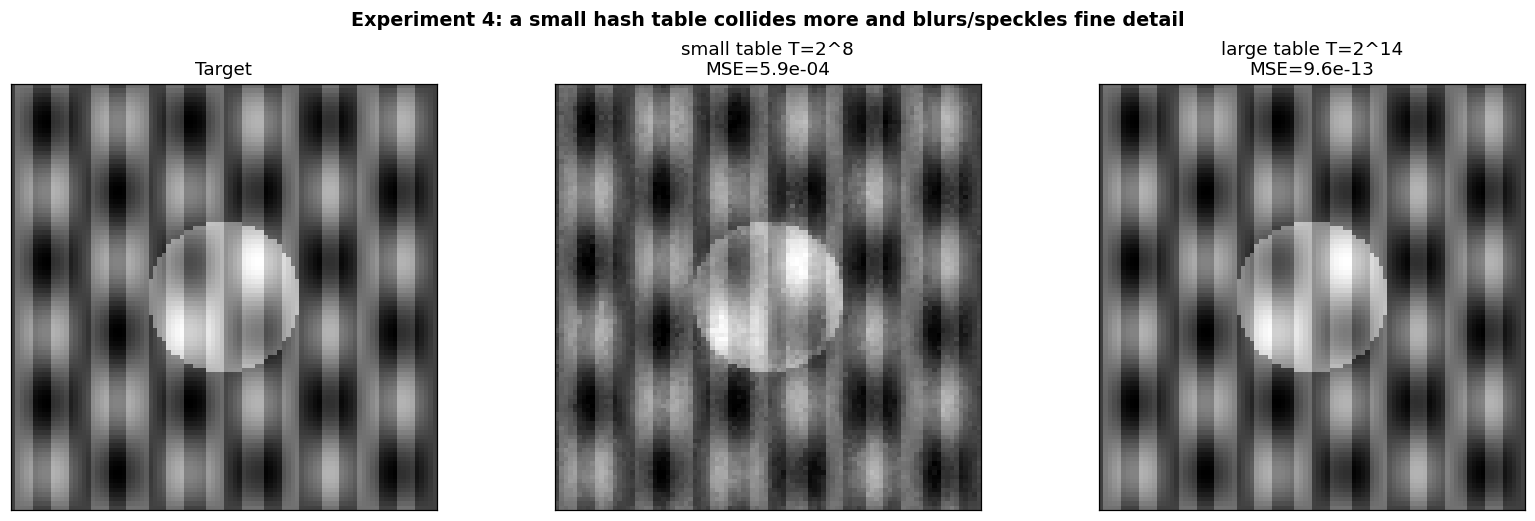

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
fig.suptitle('Experiment 4: a small hash table collides more and blurs/speckles fine detail',
             fontsize=12.5, fontweight='bold')
axes[0].imshow(img, extent=[0, 1, 0, 1], origin='lower', cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Target'); axes[0].set_xticks([]); axes[0].set_yticks([]); axes[0].grid(False)
axes[1].imshow(np.clip(results[2**8][0], 0, 1), extent=[0, 1, 0, 1], origin='lower', cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'small table T=2^8\nMSE={results[2**8][1]:.1e}')
axes[1].set_xticks([]); axes[1].set_yticks([]); axes[1].grid(False)
axes[2].imshow(np.clip(results[2**14][0], 0, 1), extent=[0, 1, 0, 1], origin='lower', cmap='gray', vmin=0, vmax=1)
axes[2].set_title(f'large table T=2^14\nMSE={results[2**14][1]:.1e}')
axes[2].set_xticks([]); axes[2].set_yticks([]); axes[2].grid(False)
plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** With a small table ($T=2^8$) the reconstruction is noticeably worse — fine detail is blurred or speckled and the final MSE is higher. With a large table ($T=2^{14}$) the image is clean.

2. **Why it looks this way:** A small table forces many distinct fine-grid vertices to share the same feature slot (collisions), so the model cannot store independent detail everywhere — the shared feature is a compromise pulled by every colliding location. A large table gives the fine levels enough independent slots.

3. **Key takeaway:** $T$ is the memory–quality knob: bigger tables resolve more detail but cost RAM. Instant-NGP accepts a controlled amount of collision (relying on multiresolution + the MLP to disambiguate) as the price for $O(1)$ lookups and tiny networks.

---
## Summary

| Experiment | Theme | Key insight |
|---|---|---|
| 1. The encoder | Structure | $L$ geometric grids share fixed-$T$ tables; fine levels outgrow $T$ and must hash |
| 2. Hash vs PE | Why it's fast | A learned grid lets the MLP be tiny and train faster, matching a big PE-MLP |
| 3. Multiresolution | Coarse→fine | Coarse levels give global structure, fine levels add detail; context tames collisions |
| 4. Hash collisions | Memory knob | Smaller $T$ = more collisions = worse detail; $T$ trades memory for quality |

### Connection to the broader theory

Instant-NGP keeps NeRF's field + [volume-rendering](../research/03-volume-rendering-ray-marching.md) pipeline but swaps *how coordinates are encoded*: instead of fixed sinusoids ([positional encoding](../research/04-positional-encoding.md)) feeding a large MLP, it looks up **learned features** on a multiresolution hash grid feeding a tiny MLP (Experiments 1–2). The multiresolution structure carries scale (Experiment 3) and the table size $T$ trades memory against hash-collision artifacts (Experiment 4). Together with empty-space skipping, this is what cut training from days to seconds. For Latent-Anything it highlights a design axis: capacity can live in network weights *or* in a spatially-structured, learnable latent table — the latter being directly inspectable and locally editable, a useful property for a system built to manipulate latents.